In [ ]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
#Load Dataset

csv_path = r'C:\Users\User\Desktop\ML Assignment\ML-Assignment\data\deliveries.csv'
df_deliveries = pd.read_csv(csv_path)

print("Dataset Loaded!")
df_deliveries.head()

Dataset Loaded!


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [ ]:

#Powerplay Runs

pp_runs = df_deliveries[df_deliveries['over'] <= 6] \
    .groupby(['match_id', 'inning'])['total_runs'] \
    .sum().reset_index()

pp_runs.head()

,match_id,inning,total_runs
0,1,1,59
1,1,2,54
2,2,1,61
3,2,2,59
4,3,1,52


In [ ]:
#Total Runs

total_runs = df_deliveries \
    .groupby(['match_id', 'inning'])['total_runs'] \
    .sum().reset_index()

total_runs.head()

,match_id,inning,total_runs
0,1,1,207
1,1,2,172
2,2,1,184
3,2,2,187
4,3,1,183


In [ ]:
#Merge data

df = pd.merge(
    pp_runs,
    total_runs,
    on=['match_id', 'inning'],
    suffixes=('_6_overs', '_total')
)

df.head()

,match_id,inning,total_runs_6_overs,total_runs_total
0,1,1,59,207
1,1,2,54,172
2,2,1,61,184
3,2,2,59,187
4,3,1,52,183


In [168]:
# Run rate
df['run_rate_pp'] = df['total_runs_6_overs'] / 6

# Interaction feature
df['pp_x_inning'] = df['total_runs_6_overs'] * df['inning']

print("Preprocessing Done:", df.shape)
df.head()

Preprocessing Done: (1284, 6)


,match_id,inning,total_runs_6_overs,total_runs_total,run_rate_pp,pp_x_inning
0,1,1,59,207,9.833333,59
1,1,2,54,172,9.000000,108
2,2,1,61,184,10.166667,61
3,2,2,59,187,9.833333,118
4,3,1,52,183,8.666667,52


In [ ]:
#define x and y
X = df[['total_runs_6_overs', 'pp_x_inning']]
y = df['total_runs_total']

print(X.head())
print(y.head())

   total_runs_6_overs  pp_x_inning
0                  59           59
1                  54          108
2                  61           61
3                  59          118
4                  52           52
0    207
1    172
2    184
3    187
4    183
Name: total_runs_total, dtype: int64


In [ ]:
#Train/Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1027, 2)
Test shape: (257, 2)


In [ ]:
#Train model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [ ]:
#Prediction

y_pred = model.predict(X_test)

print(y_pred[:5])

[129.99037797 143.73206357 173.08908135 135.56825385 152.33785379]


In [ ]:
#Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 21.823183042383558
MSE: 824.0377472460046
R2 Score: 0.22445510287381398


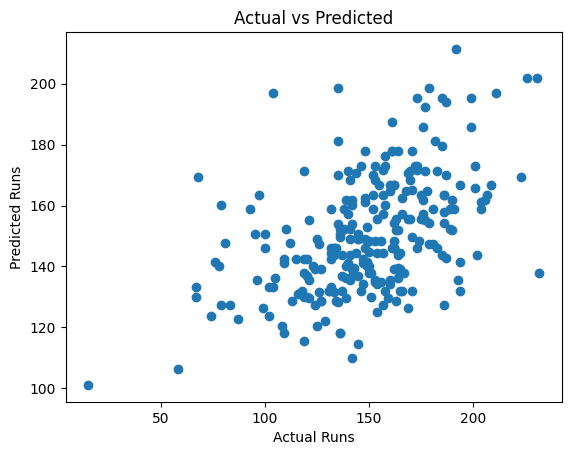

In [ ]:
#Graph

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
#Model Details

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: 90.08417113032264
Coefficient: [ 2.02623802 -0.42998974]


In [ ]:
#Train vs Test Accuracy

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R2 Score:", train_r2)
print("Test R2 Score:", test_r2)

Train R2 Score: 0.31283733974394434
Test R2 Score: 0.22445510287381398


In [ ]:
# Model eval (CM + precision, recall, F1)

from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, test_pred_labels)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred_labels))

Confusion Matrix:
 [[61 20]
 [33 14]]

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.75      0.70        81
           1       0.41      0.30      0.35        47

    accuracy                           0.59       128
   macro avg       0.53      0.53      0.52       128
weighted avg       0.56      0.59      0.57       128



In [13]:
#Import required libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score



#Read Data

df = pd.read_csv(r'C:\Users\User\Desktop\ML Assignment\ML-Assignment\data\matches.csv')

print("Rows & Columns:", df.shape)



#Data preprocessing

df = df.drop_duplicates()

df['winner'] = df['winner'].fillna('No Result')
df['toss_winner'] = df['toss_winner'].fillna('Unknown')
df['toss_decision'] = df['toss_decision'].fillna('field')
df['venue'] = df['venue'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')


#Create the target variable

df['result'] = (df['winner'] == df['team1']).astype(int)



#fearture selection

# Toss advantage
df['toss_adv'] = (df['toss_winner'] == df['team1']).astype(int)

df['toss_decision'] = df['toss_decision'].replace({
    'bat': 1,
    'field': 0
})

#Team performance score
win_map = df['winner'].value_counts().to_dict()

df['team1_score'] = df['team1'].map(win_map)
df['team2_score'] = df['team2'].map(win_map)

df['team1_score'] = df['team1_score'].fillna(0)
df['team2_score'] = df['team2_score'].fillna(0)

# Difference feature
df['score_gap'] = df['team1_score'] - df['team2_score']



#last 5 matches form

df = df.sort_values(by='date')

df['team1_form'] = df.groupby('team1')['result']\
    .rolling(window=5).mean().reset_index(level=0, drop=True)

df['team2_form'] = df.groupby('team2')['result']\
    .rolling(window=5).mean().reset_index(level=0, drop=True)

df['team1_form'] = df['team1_form'].fillna(0.5)
df['team2_form'] = df['team2_form'].fillna(0.5)

df['form_gap'] = df['team1_form'] - df['team2_form']


# Home condition
df['home_flag'] = (df['city'] == df['team1']).astype(int)



#select features and target

features = df[[
    'venue',
    'toss_adv',
    'toss_decision',
    'score_gap',
    'form_gap',
    'home_flag'
]].copy()

target = df['result'].copy()

# Remove NaN values and reset indices
mask = features.notna().all(axis=1)
features = features[mask].reset_index(drop=True)
target = target[mask].reset_index(drop=True)



#Encode categorical features

encoder = LabelEncoder()
features['venue'] = encoder.fit_transform(features['venue'])



#Train test split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)



#Feature selection

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



#Train linear regression model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#Train set evaluation

train_pred = lr_model.predict(X_train)
train_pred_labels = (train_pred > 0.5).astype(int)

train_score = accuracy_score(y_train, train_pred_labels)
print("Training Accuracy:", train_score * 100)



#Test set evaluation

test_pred = lr_model.predict(X_test)
test_pred_labels = (test_pred > 0.5).astype(int)

test_score = accuracy_score(y_test, test_pred_labels)
print("Testing Accuracy:", test_score * 100)

Rows & Columns: (636, 18)
Training Accuracy: 56.496062992125985
Testing Accuracy: 58.59375
